In [3]:
## Prepare Environment

from jaxtyping import Float, Array
import numpy as np
from typing import Callable, Union
import matplotlib.pyplot as plt

john = 316

np.random.seed(john)

def random_argmax(ary: Array) -> int:
    """Take an argmax and randomize between ties."""
    max_idx = np.flatnonzero(ary == ary.max())
    return np.random.choice(max_idx).item()


In [4]:
class MAB:
    """The Bernoulli multi-armed bandit environment."""

    def __init__(self, means: Float[Array, " K"], T: int):
        """Constructor.

        :param means: the means (success probabilities) of the reward distributions for each arm
        :param T: the time horizon
        """
        # Ensure means are between 0 and 1
        assert np.all((means >= 0) & (means <= 1)), "Means must be between 0 and 1"
        
        self.means = np.asarray(means)
        self.T = T
        self.K = self.means.size
        self.best_arm = random_argmax(self.means)

    def pull(self, k: int) -> int:
        """Pull the `k`-th arm and sample from its (Bernoulli) reward distribution."""
        # A Bernoulli trial: returns 1 with probability self.means[k]
        reward = np.random.rand() < self.means[k]
        return int(reward)

In [5]:
# pseudocode for the MAB loop

def mab_loop(mab: MAB, agent: "Agent") -> int:
    for t in range(mab.T):
        arm = agent.choose_arm()  # in 0, ..., K-1
        reward = mab.pull(arm)
        agent.update_history(arm, reward)

In [6]:
## Setting up the MAB 

mab = MAB(means=np.array([0.1, 0.8, 0.4]), T=100)

In [7]:
class Agent:
    """Stores the pull history and uses it to decide which arm to pull next.
        
    Since we are working with Bernoulli bandit,
    we can summarize the pull history concisely in a (K, 2) array.
    """

    def __init__(self, K: int, T: int):
        """The MAB agent that decides how to choose an arm given the past history."""
        self.K = K
        self.T = T
        self.rewards = []  # for plotting
        self.choices = []
        self.observations = dict()
        self.history = np.zeros((K, 2), dtype=int)

    def choose_arm(self) -> int:
        """Choose an arm of the MAB. Algorithm-specific."""
        pass

    def count(self) -> int:
        """The number of pulls made. Also the current step index."""
        return len(self.rewards)

    def update_history(self, arm: int, reward: int):
        self.rewards.append(reward)
        self.choices.append(arm)
        if arm in self.observations.keys():
            self.observations[arm] += reward
        else:
            self.observations[arm] = reward
        self.history[arm, reward] += 1

In [8]:
def regret_per_step(mab: MAB, agent: Agent):
    """Get the difference from the average reward of the optimal arm. The sum of these is the regret."""
    return [mab.means[mab.best_arm] - mab.means[arm] for arm in agent.choices]

In [9]:
## Introducing Regret, plotting the regret per step and cumulative regret

def regret_per_step(mab: MAB, agent: Agent):
    """Get the difference from the average reward of the optimal arm. The sum of these is the regret."""
    return [mab.means[mab.best_arm] - mab.means[arm] for arm in agent.choices]

def plot_strategy(mab: MAB, agent: Agent, size: int = 40):
    plt.figure(figsize=(4, 2))

    # plot reward and cumulative regret
    plt.plot(np.arange(mab.T), np.cumsum(agent.rewards), label="reward")
    cum_regret = np.cumsum(regret_per_step(mab, agent))
    plt.plot(np.arange(mab.T), cum_regret, label="cumulative regret")

    # draw colored circles for arm choices
    colors = ["red", "green", "blue"]
    color_array = [colors[k] for k in agent.choices]
    plt.scatter(np.arange(mab.T), np.zeros(mab.T), c=color_array, s = size)

    # Add legend entries for each arm
    for i, color in enumerate(colors):
        plt.scatter([], [], c=color, label=f'arm {i}')

    # labels and title
    plt.xlabel("Pull index")
    plt.legend()
    plt.show()

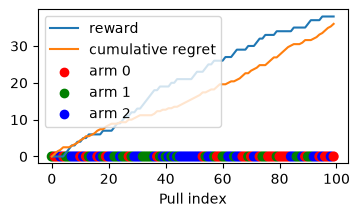

In [10]:
## Pure Exploration

class PureExploration(Agent):
    def choose_arm(self) -> int:
        """Choose an arm uniformly at random."""
        # np.random.randint(low, high) is exclusive of high, 
        # so this picks from 0, 1, ..., K-1
        choice = np.random.randint(0, self.K)
        return choice


agent = PureExploration(mab.K, mab.T)
mab_loop(mab, agent)
plot_strategy(mab, agent)

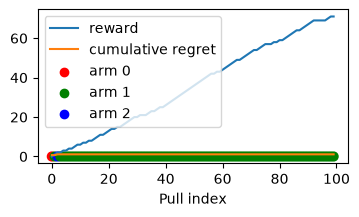

In [11]:
## Pure Greedy

class PureGreedy(Agent):
    def choose_arm(self):
        """Choose the arm with the highest reward on its first pull"""
        for arm in range(self.K):
            if arm not in self.observations.keys():
                return arm
        
        return max(self.observations, key=self.observations.get)

agent = PureGreedy(mab.K, mab.T)
mab_loop(mab, agent)
plot_strategy(mab, agent)

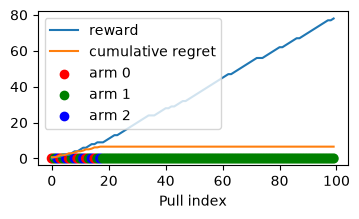

In [12]:
class ExploreThenCommit(Agent):
    def __init__(self, K: int, T: int, N_explore: int):
        super().__init__(K, T)
        self.N_explore = N_explore
        self.explored = 0
        self.window = []  # Initialize a window to track exploration
        
    def choose_arm(self):
        while self.explored < self.N_explore:
            for arm in range(self.K):
                if arm not in self.window:
                    self.window.append(arm)
                    return arm
            self.window = []
            self.explored += 1
        
        return max(self.observations, key=self.observations.get)
    
agent = ExploreThenCommit(mab.K, mab.T, mab.T // 15)
mab_loop(mab, agent)
plot_strategy(mab, agent)
                
                

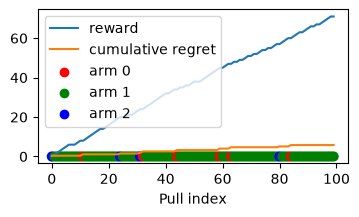

In [13]:
## Epsilon greedy

class EpsilonGreedy(Agent):
    def __init__(
        self,
        K: int,
        T: int,
        E_array: Float[Array, " T"],
    ):
        super().__init__(K, T)
        self.E_array = E_array

    def choose_arm(self):
        E = self.E_array[self.count()]
        if np.random.rand() < E:
            return np.random.randint(0, self.K)
        else:
            ## estimate the expected reward from each arm relative to how many times it has been pulled
            estimates = [self.observations[arm] / self.history[arm].sum() if self.history[arm].sum() > 0 else 0 for arm in range(self.K)]
            return random_argmax(np.array(estimates))

agent = EpsilonGreedy(mab.K, mab.T, np.full(mab.T, 0.1))
mab_loop(mab, agent)
plot_strategy(mab, agent)

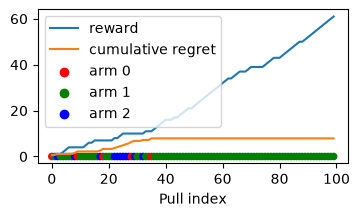

In [14]:
## Upper Confidence Bound (UCB)

class UCB(Agent):
    def __init__(self, K: int, T: int, delta: float):
        super().__init__(K, T)
        self.delta = delta
        self.window = [] # Initialize a window to track initial exploration

    def choose_arm(self):
        for arm in range(self.K):
            if arm not in self.window:
                self.window.append(arm)
                return arm
        estimates = [self.observations[arm] / self.history[arm].sum() if self.history[arm].sum() > 0 else 0 for arm in range(self.K)]
        conf_bounds = [estimate + np.sqrt(np.log((2 * len(self.choices))/ self.delta) / (2 * self.history[arm].sum())) if self.history[arm].sum() > 0 else np.inf for arm, estimate in enumerate(estimates)]
        return random_argmax(np.array(conf_bounds))


agent = UCB(mab.K, mab.T, 0.9)
mab_loop(mab, agent)
plot_strategy(mab, agent, size = 20)

In [15]:
# Intuitively, UCB prioritizes arms where:

#  estimate[arm] is large, i.e. the arm’s corresponding sample mean is high, and we’d choose it for exploitation, and
 
#  np.sqrt(np.log((2 * len(self.choices))/ self.delta) / (2 * self.history[arm].sum())) is large, 
# self.history[arm].sum() i.e. is small and we’re still uncertain about the arm, and we’d choose it for exploration.

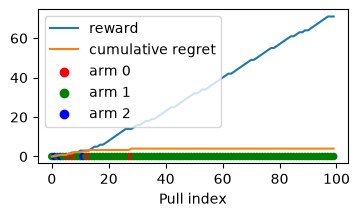

In [16]:
## Thompson Sampling 

class ThompsonSampling(Agent):
    def choose_arm(self) -> int:
        """
        Sample from the posterior Beta distribution for each arm and 
        select the arm with the highest sample.
        """
        # Beta(1 + successes, 1 + failures)
        samples = [
            np.random.beta(1 + self.history[arm, 1], 1 + self.history[arm, 0])
            for arm in range(self.K)
        ]
        return random_argmax(np.array(samples))

agent = ThompsonSampling(mab.K, mab.T)
mab_loop(mab, agent)
plot_strategy(mab, agent, size = 20)

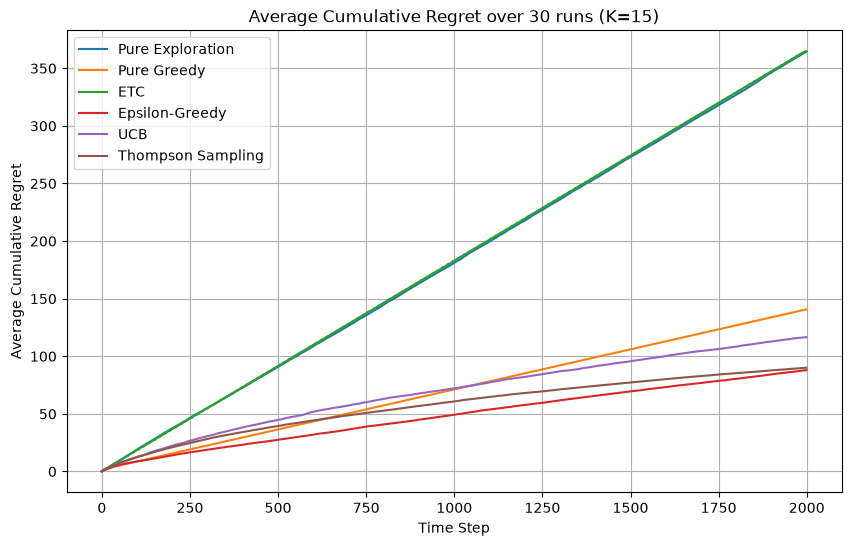

In [ ]:
## Regret Comparison Across Algorithms
import matplotlib.pyplot as plt
def run_experiment(algorithm_class, means, T, num_runs=10):
    K = len(means)
    all_regrets = []
    
    for _ in range(num_runs):
        mab = MAB(means=means, T=T)
        if algorithm_class == EpsilonGreedy:
            agent = algorithm_class(K, T, np.full(T, 0.1))
        elif algorithm_class == ExploreThenCommit:
            agent = algorithm_class(K, T, T // 20)
        elif algorithm_class == UCB:
            agent = algorithm_class(K, T, 0.9)
        else:
            agent = algorithm_class(K, T)
            
        mab_loop(mab, agent)
        all_regrets.append(np.cumsum(regret_per_step(mab, agent)))
        
    return np.mean(all_regrets, axis=0)
T = 2000
K = 15
rng = np.random.default_rng(seed=john)
means = rng.uniform(low = 0.0, high = 0.5, size = K)
algorithms = [
    (PureExploration, "Pure Exploration"),
    (PureGreedy, "Pure Greedy"),
    (ExploreThenCommit, "ETC"),
    (EpsilonGreedy, "Epsilon-Greedy"),
    (UCB, "UCB"),
    (ThompsonSampling, "Thompson Sampling")
]
plt.figure(figsize=(10, 6))
for alg_class, name in algorithms:
    avg_regret = run_experiment(alg_class, means, T, num_runs = 20)
    plt.plot(avg_regret, label=name)
plt.xlabel("Time Step")
plt.ylabel("Average Cumulative Regret")
plt.title(f"Average Cumulative Regret over {30} runs (K={K})")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
means

array([0.49826327, 0.0270853 , 0.48134567, 0.25855245, 0.05484566,
       0.40018555, 0.19286786, 0.44376694, 0.15378825, 0.39763402,
       0.45252519, 0.45923055, 0.11986269, 0.48313332, 0.31019107])